# Kernel-Rev vs Kernel-NonRev: Likelihood Computation Analysis

Comparing IQ-TREE 3.1.0 **kernel-rev** (revised kernel) vs **kernel-nonrev** (non-revised kernel) across:

- **4 backends**: Vanilla (1 CPU thread), OMP 10 threads, OMP 48 threads, OpenACC (GPU V100)
- **2 data types**: DNA (GTR+I+G4) and Amino Acid (LG+I+G4)
- **3 alignment lengths**: 100, 10,000, 100,000 sites
- **100 taxa** per analysis

In [1]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_BASE = '/Users/u7826985/Projects/Nvidia/results/2026_04_02_kernelrev'
SAVE_DIR = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_04_02_kernelrev'

# Backend labels
backend_labels = {
    'VANILA': '1 CPU thread',
    'OMP_10': '10 CPU threads',
    'OMP_48': '48 CPU threads',
    'OPENACC': 'GPU (V100)'
}
backend_order = ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']

# Kernel labels
kernel_labels = {'kernelrev': 'Kernel-Rev', 'kernelnonrev': 'Kernel-NonRev'}

# Colors for kernel comparison
kernel_colors = {'Kernel-Rev': '#2ca02c', 'Kernel-NonRev': '#d62728'}
kernel_hatches = {'Kernel-Rev': '', 'Kernel-NonRev': '//'}

# Colors for backends
backend_colors = {
    '1 CPU thread': '#1f77b4',
    '10 CPU threads': '#ff7f0e',
    '48 CPU threads': '#2ca02c',
    'GPU (V100)': '#d62728'
}

def fmt_time(sec):
    if pd.isna(sec): return 'N/A'
    if sec < 60: return f'{sec:.1f}s'
    if sec < 3600: return f'{sec/60:.1f}m'
    return f'{sec/3600:.1f}h'

## 1. Data Loading and Parsing

In [2]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for key metrics."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()

    m = re.search(r'Best-fit model according to BIC:\s+(\S+)', content)
    if m: data['best_model'] = m.group(1)

    m = re.search(r'Log-likelihood of the tree:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))

    m = re.search(r'Bayesian information criterion \(BIC\) score:\s+([\d.]+)', content)
    if m: data['bic'] = float(m.group(1))

    m = re.search(r'Akaike information criterion \(AIC\) score:\s+([\d.]+)', content)
    if m: data['aic'] = float(m.group(1))

    m = re.search(r'Number of free parameters.*?:\s+(\d+)', content)
    if m: data['free_params'] = int(m.group(1))

    m = re.search(r'Gamma shape alpha:\s+([\d.]+)', content)
    if m: data['gamma_alpha'] = float(m.group(1))

    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))

    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))

    return data

def parse_log_file(filepath):
    """Parse .log file as fallback."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()

    m = re.search(r'Best-fit model:\s+(\S+)\s+chosen', content)
    if m: data['best_model'] = m.group(1)

    m = re.search(r'Optimal log-likelihood:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))

    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))

    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))

    return data

def parse_model_table(filepath):
    """Parse the 'List of models sorted by BIC scores' table from .iqtree file."""
    models = []
    with open(filepath, 'r') as f:
        content = f.read()

    table_match = re.search(r'Model\s+LogL\s+AIC.*?BIC.*?\n(.*?)(?:\n\n|\nAkaike|\nBayesian)', content, re.DOTALL)
    if not table_match:
        return models

    for line in table_match.group(1).strip().split('\n'):
        line = line.strip()
        if not line or line.startswith('---'):
            continue
        parts = line.split()
        if len(parts) >= 9:
            try:
                model_name = parts[0]
                lnl = float(parts[1])
                aic = float(parts[2])
                bic = float(parts[-3])
                models.append({'model': model_name, 'lnL': lnl, 'AIC': aic, 'BIC': bic})
            except (ValueError, IndexError):
                continue
    return models

def load_all_results():
    """Load results for both kernel types, both data types, all backends."""
    records = []
    lengths = [100, 1000, 10000, 100000, 1000000, 10000000]
    kernels = ['kernelrev', 'kernelnonrev']
    backends = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']
    data_types = ['DNA', 'AA']

    for data_type in data_types:
        for length in lengths:
            len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
            if not os.path.isdir(len_dir):
                continue

            for kernel in kernels:
                for backend in backends:
                    # Try .iqtree first
                    pattern = os.path.join(len_dir, f'*_{kernel}_{data_type}_*_{backend}_*.iqtree')
                    iqtree_files = glob.glob(pattern)
                    if iqtree_files:
                        data = parse_iqtree_file(iqtree_files[0])
                    else:
                        # Fallback to .log
                        pattern = os.path.join(len_dir, f'*_{kernel}_{data_type}_*_{backend}_*.log')
                        log_files = glob.glob(pattern)
                        if log_files:
                            data = parse_log_file(log_files[0])
                        else:
                            continue

                    if not data or 'wall_time_sec' not in data:
                        continue

                    data['length'] = length
                    data['kernel'] = kernel
                    data['kernel_label'] = kernel_labels[kernel]
                    data['backend'] = backend
                    data['backend_label'] = backend_labels[backend]
                    data['data_type'] = data_type
                    records.append(data)

    return pd.DataFrame(records)

df = load_all_results()
print(f"Total records parsed: {len(df)}")
print(f"\nData types: {sorted(df['data_type'].unique())}")
print(f"Kernels: {sorted(df['kernel_label'].unique())}")
print(f"Backends: {sorted(df['backend_label'].unique())}")
print(f"Lengths: {sorted(df['length'].unique())}")

df_dna = df[df['data_type'] == 'DNA'].copy()
df_aa = df[df['data_type'] == 'AA'].copy()
print(f"\nDNA records: {len(df_dna)}, AA records: {len(df_aa)}")

Total records parsed: 46

Data types: ['AA', 'DNA']
Kernels: ['Kernel-NonRev', 'Kernel-Rev']
Backends: ['1 CPU thread', '10 CPU threads', '48 CPU threads', 'GPU (V100)']
Lengths: [100, 10000, 100000]

DNA records: 24, AA records: 22


In [3]:
# Full summary table
display_cols = ['data_type', 'length', 'kernel_label', 'backend_label', 'best_model', 'log_likelihood', 'wall_time_sec', 'cpu_time_sec']
summary = df[display_cols].sort_values(['data_type', 'length', 'backend_label', 'kernel_label']).reset_index(drop=True)
summary['wall_time_fmt'] = summary['wall_time_sec'].apply(fmt_time)
summary['cpu_time_fmt'] = summary['cpu_time_sec'].apply(fmt_time)
print(f"Full results summary ({len(summary)} runs):")
summary

Full results summary (46 runs):


,data_type,length,kernel_label,backend_label,best_model,log_likelihood,wall_time_sec,cpu_time_sec,wall_time_fmt,cpu_time_fmt
0,AA,100,Kernel-NonRev,1 CPU thread,LG+G4,-7.676571e+03,75.74230,75.37500,1.3m,1.3m
1,AA,100,Kernel-Rev,1 CPU thread,LG+G4,-7.676571e+03,44.99000,44.91140,45.0s,44.9s
2,AA,100,Kernel-NonRev,10 CPU threads,LG+G4,-7.676571e+03,37.48470,374.12400,37.5s,6.2m
3,AA,100,Kernel-Rev,10 CPU threads,LG+G4,-7.676571e+03,11.79320,114.76000,11.8s,1.9m
4,AA,100,Kernel-NonRev,48 CPU threads,LG+G4,-7.676571e+03,43.84400,532.23800,43.8s,8.9m
5,AA,100,Kernel-Rev,48 CPU threads,LG+G4,-7.676571e+03,16.59020,206.28400,16.6s,3.4m
6,AA,100,Kernel-NonRev,GPU (V100),LG+G4,-7.676571e+03,83.83120,83.79030,1.4m,1.4m
7,AA,100,Kernel-Rev,GPU (V100),LG+G4,-7.676571e+03,83.89140,83.81470,1.4m,1.4m
8,AA,10000,Kernel-NonRev,1 CPU thread,LG+G4,-8.073514e+05,4404.09000,4251.34000,1.2h,1.2h
9,AA,10000,Kernel-Rev,1 CPU thread,LG+G4,-8.073514e+05,5099.42000,5062.43000,1.4h,1.4h


---
# Part 1: DNA Analysis (GTR+I+G4)

## 2. Model Selection Agreement (DNA)

In [4]:
# Model selection comparison: rev vs nonrev for each backend + length (DNA)
model_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='best_model', aggfunc='first')
print("Model Selection: Kernel-Rev vs Kernel-NonRev (DNA)")
print("=" * 70)
for length in sorted(df_dna['length'].unique()):
    sub = model_comp_dna.loc[length] if length in model_comp_dna.index.get_level_values(0) else None
    if sub is None: continue
    print(f"\nAlignment length: {length:,}")
    for backend in backend_order:
        if backend in sub.index:
            rev = sub.loc[backend, 'Kernel-Rev'] if 'Kernel-Rev' in sub.columns else 'N/A'
            nonrev = sub.loc[backend, 'Kernel-NonRev'] if 'Kernel-NonRev' in sub.columns else 'N/A'
            match = "MATCH" if rev == nonrev else "DIFFER"
            print(f"  {backend:20s}  Rev: {str(rev):20s}  NonRev: {str(nonrev):20s}  [{match}]")

Model Selection: Kernel-Rev vs Kernel-NonRev (DNA)

Alignment length: 100
  1 CPU thread          Rev: F81+F+ASC+G4          NonRev: F81+F+ASC+G4          [MATCH]
  10 CPU threads        Rev: F81+F+ASC+G4          NonRev: F81+F+ASC+G4          [MATCH]
  48 CPU threads        Rev: F81+F+ASC+G4          NonRev: F81+F+ASC+G4          [MATCH]
  GPU (V100)            Rev: F81+F+ASC+G4          NonRev: F81+F+ASC+G4          [MATCH]

Alignment length: 10,000
  1 CPU thread          Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]
  10 CPU threads        Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]
  48 CPU threads        Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]
  GPU (V100)            Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]

Alignment length: 100,000
  1 CPU thread          Rev: F81+F+G4              NonRev: F81+F+G4              [MATCH]
  10 CPU threads        Rev: F81+F+G4              NonRev: F81+F+G4     

## 3. Log-Likelihood Comparison (DNA)

Check whether kernel-rev and kernel-nonrev produce the same log-likelihood values for each backend and alignment length.

In [5]:
# Log-likelihood comparison: rev vs nonrev (DNA)
lnl_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='log_likelihood', aggfunc='first')
if 'Kernel-Rev' in lnl_comp_dna.columns and 'Kernel-NonRev' in lnl_comp_dna.columns:
    lnl_comp_dna['abs_diff'] = (lnl_comp_dna['Kernel-Rev'] - lnl_comp_dna['Kernel-NonRev']).abs()
    lnl_comp_dna['rel_diff_pct'] = (lnl_comp_dna['abs_diff'] / lnl_comp_dna['Kernel-NonRev'].abs() * 100)

print("Log-Likelihood: Kernel-Rev vs Kernel-NonRev (DNA)")
print("=" * 90)
lnl_comp_dna.round(4)

Log-Likelihood: Kernel-Rev vs Kernel-NonRev (DNA)


kernel_label           Kernel-NonRev    Kernel-Rev  abs_diff  rel_diff_pct
length backend_label                                                      
100    1 CPU thread    -4.909972e+03 -4.907728e+03    2.2448        0.0457
       10 CPU threads  -4.909972e+03 -4.907728e+03    2.2448        0.0457
       48 CPU threads  -4.909972e+03 -4.907728e+03    2.2448        0.0457
       GPU (V100)      -4.907728e+03 -4.907728e+03    0.0000        0.0000
10000  1 CPU thread    -5.642088e+05 -5.642088e+05    0.0005        0.0000
       10 CPU threads  -5.642088e+05 -5.642088e+05    0.0001        0.0000
       48 CPU threads  -5.642088e+05 -5.642088e+05    0.0001        0.0000
       GPU (V100)      -5.642088e+05 -5.642088e+05    0.0000        0.0000
100000 1 CPU thread    -5.692985e+06 -5.692985e+06    0.0000        0.0000
       10 CPU threads  -5.692985e+06 -5.692985e+06    0.0000        0.0000
       48 CPU threads  -5.692985e+06 -5.692985e+06    0.0000        0.0000
       GPU (V100)      -5.692985e+06 -5.692985e+06    0.0000        0.0000

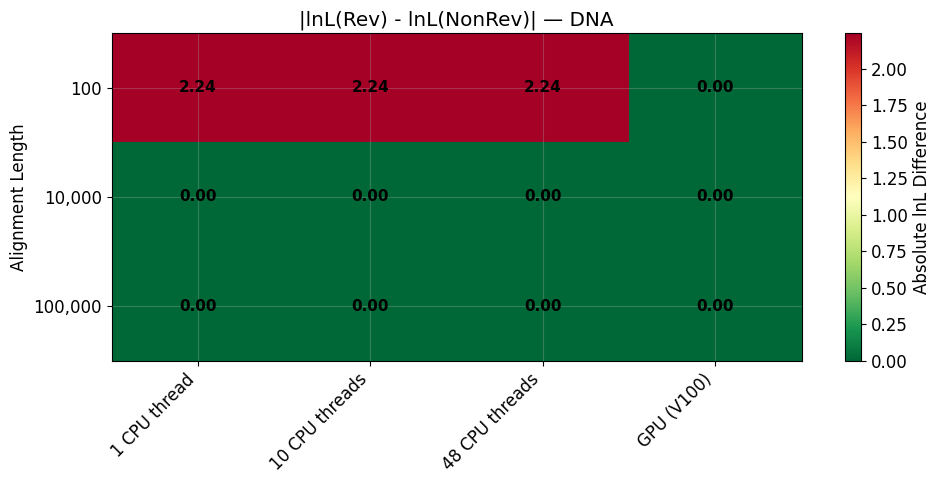

In [6]:
# Log-likelihood difference heatmap (DNA)
if 'abs_diff' in lnl_comp_dna.columns:
    diff_pivot = lnl_comp_dna['abs_diff'].unstack(level='backend_label')
    diff_pivot = diff_pivot[[c for c in backend_order if c in diff_pivot.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot.values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(diff_pivot.columns)))
    ax.set_xticklabels(diff_pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — DNA')

    for i in range(len(diff_pivot.index)):
        for j in range(len(diff_pivot.columns)):
            val = diff_pivot.iloc[i, j]
            if not pd.isna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 4. Wall-Clock Runtime Comparison (DNA)

Side-by-side wall-clock time: kernel-rev vs kernel-nonrev for each backend.

In [7]:
# Wall-clock time pivot table (DNA)
time_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='wall_time_sec', aggfunc='first')
if 'Kernel-Rev' in time_comp_dna.columns and 'Kernel-NonRev' in time_comp_dna.columns:
    time_comp_dna['ratio_rev_over_nonrev'] = time_comp_dna['Kernel-Rev'] / time_comp_dna['Kernel-NonRev']
    time_comp_dna['pct_change'] = (time_comp_dna['Kernel-Rev'] - time_comp_dna['Kernel-NonRev']) / time_comp_dna['Kernel-NonRev'] * 100

print("Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)")
print("ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER")
print("=" * 90)
time_comp_dna.round(3)

Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)
ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER


kernel_label           Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev  \
length backend_label                                                      
100    1 CPU thread            3.364       5.852                  1.740   
       10 CPU threads          8.812       8.859                  1.005   
       48 CPU threads          5.775     146.616                 25.387   
       GPU (V100)             58.542      57.225                  0.977   
10000  1 CPU thread          396.556     427.644                  1.078   
       10 CPU threads         95.905     162.609                  1.696   
       48 CPU threads         53.868      49.935                  0.927   
       GPU (V100)             61.243      62.440                  1.020   
100000 1 CPU thread         3383.543    3848.550                  1.137   
       10 CPU threads        527.334     441.178                  0.837   
       48 CPU threads        208.927     230.140                  1.102   
       GPU (V100)            118.012     118.453                  1.004   

kernel_label           pct_change  
length backend_label               
100    1 CPU thread        73.976  
       10 CPU threads       0.535  
       48 CPU threads    2438.748  
       GPU (V100)          -2.250  
10000  1 CPU thread         7.839  
       10 CPU threads      69.552  
       48 CPU threads      -7.301  
       GPU (V100)           1.954  
100000 1 CPU thread        13.743  
       10 CPU threads     -16.338  
       48 CPU threads      10.153  
       GPU (V100)           0.374

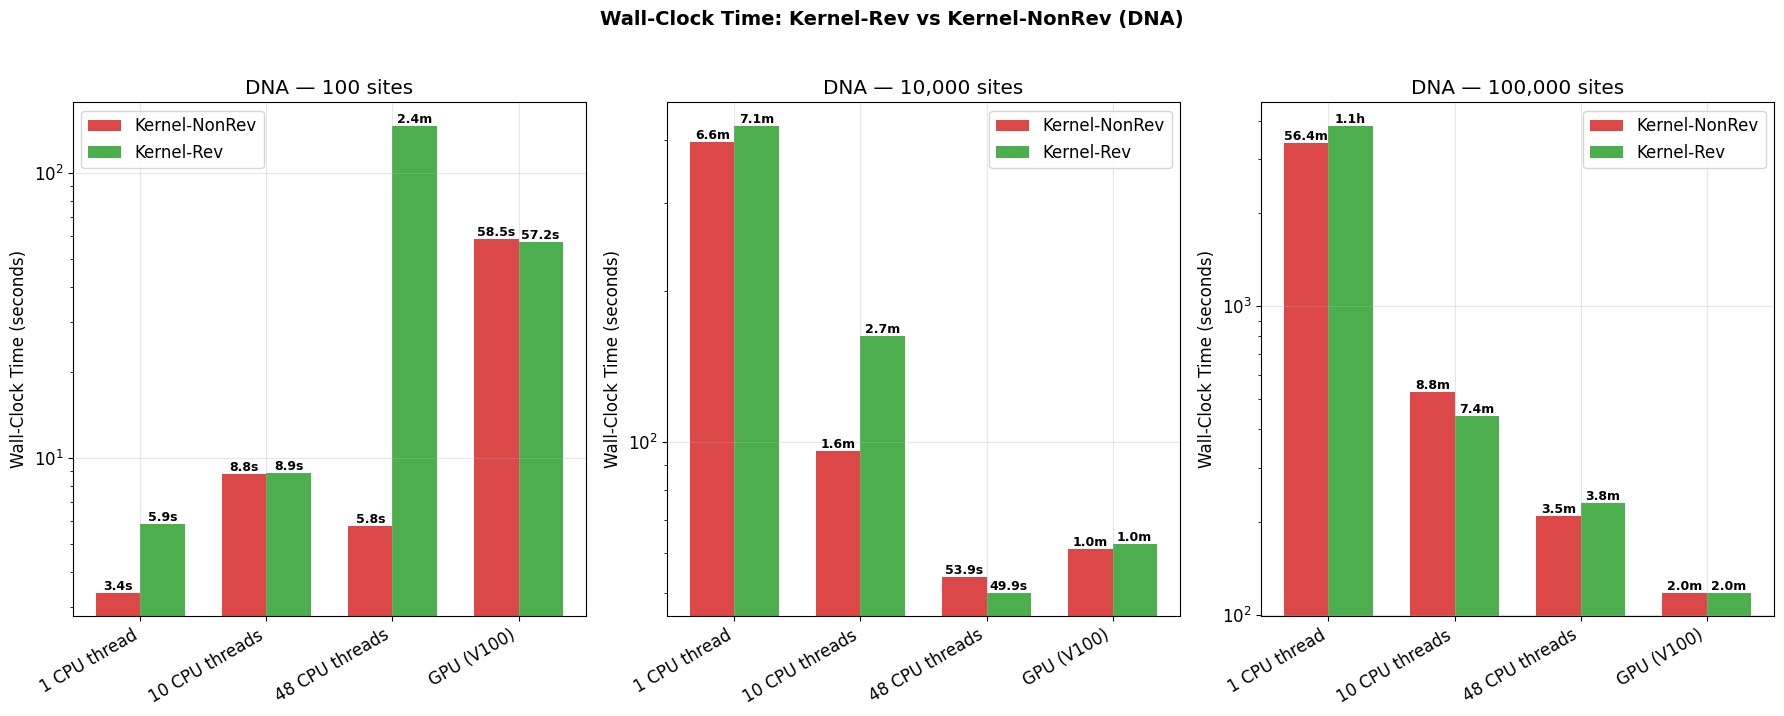

In [8]:
# Grouped bar chart: wall-clock time rev vs nonrev per backend, one subplot per alignment length (DNA)
dna_lengths = sorted(df_dna['length'].unique())
n_lengths = len(dna_lengths)

fig, axes = plt.subplots(1, n_lengths, figsize=(6 * n_lengths, 7), sharey=False)
if n_lengths == 1: axes = [axes]

for ax, length in zip(axes, dna_lengths):
    sub = df_dna[df_dna['length'] == length]
    backends_present = [b for b in backend_order if b in sub['backend_label'].values]
    x = np.arange(len(backends_present))
    width = 0.35

    rev_times = []
    nonrev_times = []
    for b in backends_present:
        rev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-Rev')]['wall_time_sec']
        nonrev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-NonRev')]['wall_time_sec']
        rev_times.append(rev_val.values[0] if len(rev_val) > 0 else 0)
        nonrev_times.append(nonrev_val.values[0] if len(nonrev_val) > 0 else 0)

    bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
    bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

    # Add value labels on bars
    for bar_group in [bars1, bars2]:
        for bar in bar_group:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(backends_present, rotation=30, ha='right')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'DNA — {length:,} sites')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (DNA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'dna_walltime_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Speedup Ratio: NonRev/Rev (DNA)

Ratio = NonRev_time / Rev_time. Values > 1 mean kernel-rev is faster; < 1 means kernel-nonrev is faster.

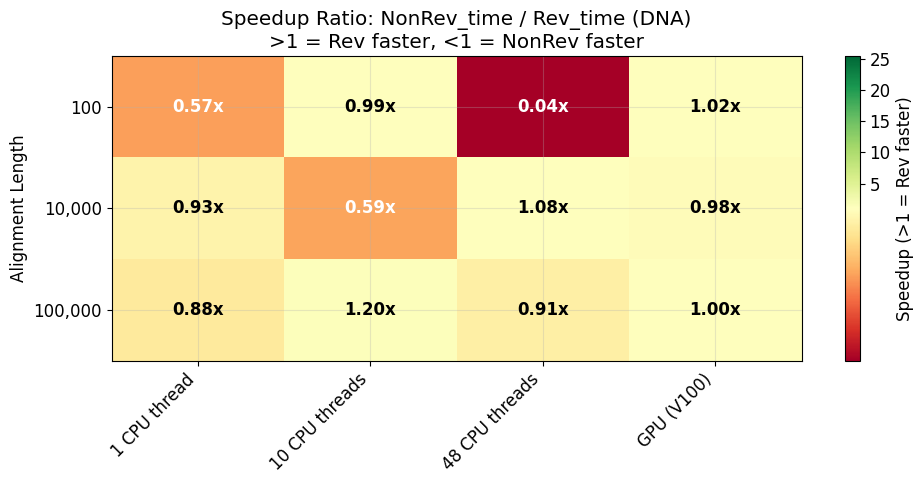

In [9]:
# Speedup heatmap: NonRev_time / Rev_time (DNA)
if 'Kernel-Rev' in time_comp_dna.columns and 'Kernel-NonRev' in time_comp_dna.columns:
    speedup = (time_comp_dna['Kernel-NonRev'] / time_comp_dna['Kernel-Rev']).unstack(level='backend_label')
    speedup = speedup[[c for c in backend_order if c in speedup.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    # Diverging colormap centered at 1.0
    vmin = min(speedup.min().min(), 1/speedup.max().max())
    vmax = max(speedup.max().max(), 1/speedup.min().min())
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

    im = ax.imshow(speedup.values, cmap='RdYlGn', norm=norm, aspect='auto')
    ax.set_xticks(range(len(speedup.columns)))
    ax.set_xticklabels(speedup.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev_time / Rev_time (DNA)\n>1 = Rev faster, <1 = NonRev faster')

    for i in range(len(speedup.index)):
        for j in range(len(speedup.columns)):
            val = speedup.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 6. CPU Time (Total Compute) Comparison (DNA)

In [10]:
# CPU time comparison (DNA)
cpu_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='cpu_time_sec', aggfunc='first')
if 'Kernel-Rev' in cpu_comp_dna.columns and 'Kernel-NonRev' in cpu_comp_dna.columns:
    cpu_comp_dna['ratio_rev_over_nonrev'] = cpu_comp_dna['Kernel-Rev'] / cpu_comp_dna['Kernel-NonRev']

print("CPU Time (total compute): Kernel-Rev vs Kernel-NonRev (DNA)")
print("=" * 90)
cpu_comp_dna.round(3)

CPU Time (total compute): Kernel-Rev vs Kernel-NonRev (DNA)


kernel_label           Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev
length backend_label                                                   
100    1 CPU thread            3.185       5.761                  1.809
       10 CPU threads         81.789      86.973                  1.063
       48 CPU threads         68.544    2905.680                 42.392
       GPU (V100)             58.108      57.209                  0.985
10000  1 CPU thread          392.644     423.640                  1.079
       10 CPU threads        944.147    1486.960                  1.575
       48 CPU threads       2507.740    2289.060                  0.913
       GPU (V100)             61.174      62.328                  1.019
100000 1 CPU thread         3324.198    3812.075                  1.147
       10 CPU threads       5122.565    4260.559                  0.832
       48 CPU threads       9505.573   10353.240                  1.089
       GPU (V100)            116.553     116.973                  1.004

## 7. Per-Model Log-Likelihood Comparison (DNA)

Compare individual model log-likelihoods between kernel-rev and kernel-nonrev to check numerical consistency.

In [11]:
# Per-model lnL comparison (DNA)
def load_model_details_kernelrev(data_type, lengths_to_use):
    """Load per-model results for rev vs nonrev comparison."""
    all_records = []
    kernels = ['kernelrev', 'kernelnonrev']
    backends = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']

    for length in lengths_to_use:
        len_dir = os.path.join(RESULTS_BASE, data_type, f'len_{length}')
        if not os.path.isdir(len_dir):
            continue
        for kernel in kernels:
            for backend in backends:
                pattern = os.path.join(len_dir, f'*_{kernel}_{data_type}_*_{backend}_*.iqtree')
                iqtree_files = glob.glob(pattern)
                if not iqtree_files:
                    continue
                models = parse_model_table(iqtree_files[0])
                for m in models:
                    m['length'] = length
                    m['kernel'] = kernel
                    m['kernel_label'] = kernel_labels[kernel]
                    m['backend'] = backend
                    m['backend_label'] = backend_labels[backend]
                    all_records.append(m)

    return pd.DataFrame(all_records)

model_df_dna = load_model_details_kernelrev('DNA', sorted(df_dna['length'].unique()))
print(f"Parsed {len(model_df_dna)} model evaluations across DNA runs")

# For each length + backend, compare per-model lnL between rev and nonrev
if len(model_df_dna) > 0:
    # Pivot: for each (length, backend, model), get lnL for rev and nonrev
    comp = model_df_dna.pivot_table(index=['length', 'backend_label', 'model'], columns='kernel_label', values='lnL', aggfunc='first')
    if 'Kernel-Rev' in comp.columns and 'Kernel-NonRev' in comp.columns:
        comp['abs_diff'] = (comp['Kernel-Rev'] - comp['Kernel-NonRev']).abs()
        comp = comp.dropna(subset=['Kernel-Rev', 'Kernel-NonRev'])

        print(f"\nMax |lnL diff| across all models: {comp['abs_diff'].max():.6f}")
        print(f"Mean |lnL diff|: {comp['abs_diff'].mean():.6f}")
        print(f"Models with |diff| > 0.01: {(comp['abs_diff'] > 0.01).sum()} / {len(comp)}")

        # Show worst cases
        worst = comp.nlargest(10, 'abs_diff')
        print("\nTop 10 largest per-model lnL differences (DNA):")
        worst.round(4)

Parsed 2223 model evaluations across DNA runs

Max |lnL diff| across all models: 3.054000
Mean |lnL diff|: 0.329798
Models with |diff| > 0.01: 122 / 816

Top 10 largest per-model lnL differences (DNA):


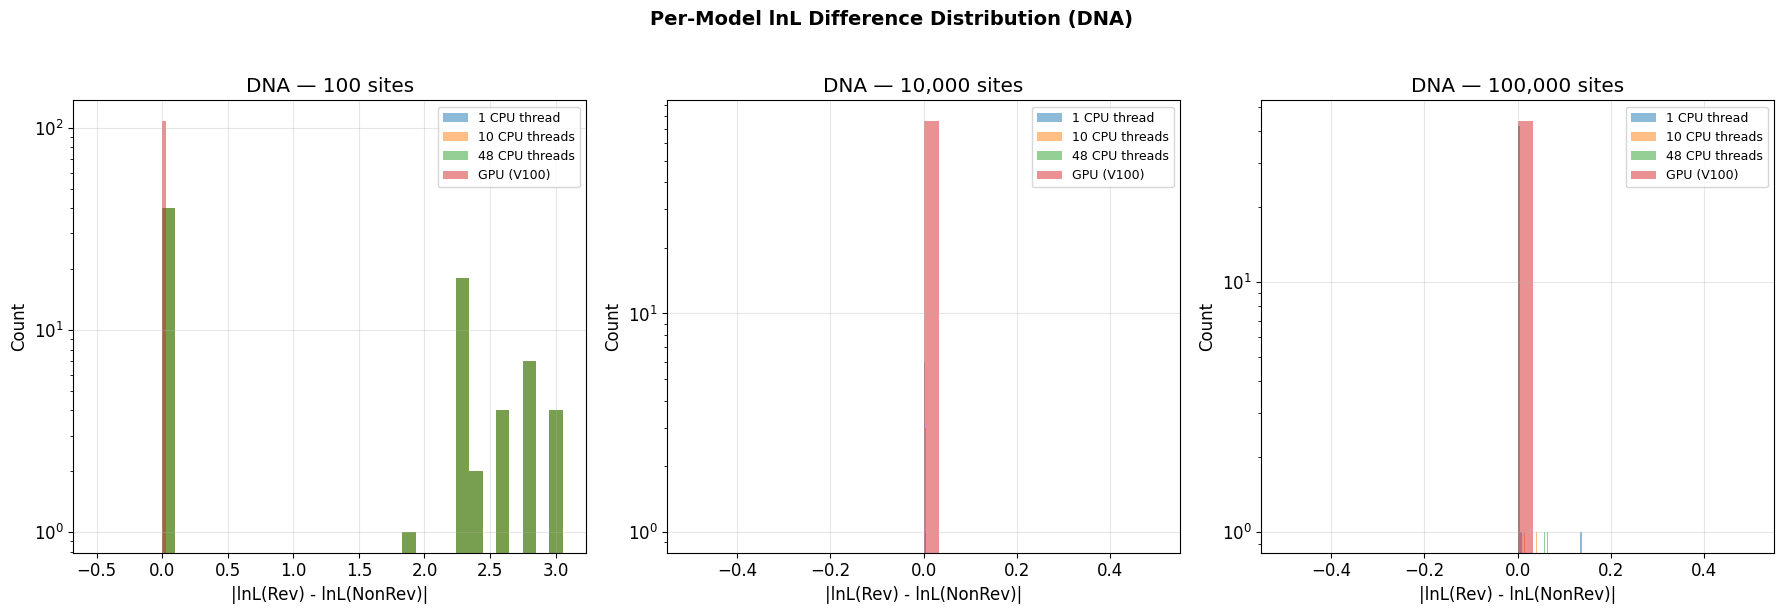

In [12]:
# Per-model lnL difference distribution plot (DNA)
if len(model_df_dna) > 0 and 'abs_diff' in comp.columns:
    fig, axes = plt.subplots(1, len(dna_lengths), figsize=(6 * len(dna_lengths), 6))
    if len(dna_lengths) == 1: axes = [axes]

    for ax, length in zip(axes, dna_lengths):
        sub = comp.loc[length] if length in comp.index.get_level_values(0) else pd.DataFrame()
        if len(sub) == 0: continue

        for backend in backend_order:
            if backend in sub.index.get_level_values(0):
                diffs = sub.loc[backend, 'abs_diff'].values
                ax.hist(diffs, bins=30, alpha=0.5, label=backend, color=backend_colors.get(backend, 'gray'))

        ax.set_xlabel('|lnL(Rev) - lnL(NonRev)|')
        ax.set_ylabel('Count')
        ax.set_title(f'DNA — {length:,} sites')
        ax.legend(fontsize=9)
        ax.set_yscale('log')

    plt.suptitle('Per-Model lnL Difference Distribution (DNA)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'dna_permodel_lnl_dist.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 8. Gamma Shape Alpha Comparison (DNA)

In [13]:
# Gamma shape alpha comparison (DNA)
if 'gamma_alpha' in df_dna.columns:
    gamma_comp_dna = df_dna.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='gamma_alpha', aggfunc='first')
    if 'Kernel-Rev' in gamma_comp_dna.columns and 'Kernel-NonRev' in gamma_comp_dna.columns:
        gamma_comp_dna['abs_diff'] = (gamma_comp_dna['Kernel-Rev'] - gamma_comp_dna['Kernel-NonRev']).abs()
    print("Gamma Shape Alpha: Kernel-Rev vs Kernel-NonRev (DNA)")
    print("=" * 70)
    display(gamma_comp_dna.round(6))

Gamma Shape Alpha: Kernel-Rev vs Kernel-NonRev (DNA)


kernel_label           Kernel-NonRev  Kernel-Rev  abs_diff
length backend_label                                      
100    1 CPU thread           0.8627      0.8172    0.0455
       10 CPU threads         0.8627      0.8172    0.0455
       48 CPU threads         0.8627      0.8172    0.0455
       GPU (V100)             0.8172      0.8172    0.0000
10000  1 CPU thread           0.9844      0.9843    0.0001
       10 CPU threads         0.9844      0.9844    0.0000
       48 CPU threads         0.9844      0.9844    0.0000
       GPU (V100)             0.9844      0.9844    0.0000
100000 1 CPU thread           1.0090      1.0090    0.0000
       10 CPU threads         1.0090      1.0090    0.0000
       48 CPU threads         1.0090      1.0090    0.0000
       GPU (V100)             1.0090      1.0090    0.0000

---
# Part 2: Amino Acid Analysis (LG+I+G4)

## 9. Model Selection Agreement (AA)

In [14]:
# Model selection comparison (AA)
model_comp_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='best_model', aggfunc='first')
print("Model Selection: Kernel-Rev vs Kernel-NonRev (AA)")
print("=" * 70)
for length in sorted(df_aa['length'].unique()):
    sub = model_comp_aa.loc[length] if length in model_comp_aa.index.get_level_values(0) else None
    if sub is None: continue
    print(f"\nAlignment length: {length:,}")
    for backend in backend_order:
        if backend in sub.index:
            rev = sub.loc[backend, 'Kernel-Rev'] if 'Kernel-Rev' in sub.columns else 'N/A'
            nonrev = sub.loc[backend, 'Kernel-NonRev'] if 'Kernel-NonRev' in sub.columns else 'N/A'
            match = "MATCH" if rev == nonrev else "DIFFER"
            print(f"  {backend:20s}  Rev: {str(rev):20s}  NonRev: {str(nonrev):20s}  [{match}]")

Model Selection: Kernel-Rev vs Kernel-NonRev (AA)

Alignment length: 100
  1 CPU thread          Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  10 CPU threads        Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  48 CPU threads        Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  GPU (V100)            Rev: LG+G4                 NonRev: LG+G4                 [MATCH]

Alignment length: 10,000
  1 CPU thread          Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  10 CPU threads        Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  48 CPU threads        Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  GPU (V100)            Rev: LG+G4                 NonRev: LG+G4                 [MATCH]

Alignment length: 100,000
  10 CPU threads        Rev: LG+G4                 NonRev: LG+G4                 [MATCH]
  48 CPU threads        Rev: LG+G4                 NonRev: LG+G4         

## 10. Log-Likelihood Comparison (AA)

In [15]:
# Log-likelihood comparison (AA)
lnl_comp_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='log_likelihood', aggfunc='first')
if 'Kernel-Rev' in lnl_comp_aa.columns and 'Kernel-NonRev' in lnl_comp_aa.columns:
    lnl_comp_aa['abs_diff'] = (lnl_comp_aa['Kernel-Rev'] - lnl_comp_aa['Kernel-NonRev']).abs()
    lnl_comp_aa['rel_diff_pct'] = (lnl_comp_aa['abs_diff'] / lnl_comp_aa['Kernel-NonRev'].abs() * 100)

print("Log-Likelihood: Kernel-Rev vs Kernel-NonRev (AA)")
print("=" * 90)
lnl_comp_aa.round(4)

Log-Likelihood: Kernel-Rev vs Kernel-NonRev (AA)


kernel_label           Kernel-NonRev    Kernel-Rev  abs_diff  rel_diff_pct
length backend_label                                                      
100    1 CPU thread    -7.676571e+03 -7.676571e+03    0.0000           0.0
       10 CPU threads  -7.676571e+03 -7.676571e+03    0.0000           0.0
       48 CPU threads  -7.676571e+03 -7.676571e+03    0.0000           0.0
       GPU (V100)      -7.676571e+03 -7.676571e+03    0.0000           0.0
10000  1 CPU thread    -8.073514e+05 -8.073514e+05    0.0000           0.0
       10 CPU threads  -8.073514e+05 -8.073514e+05    0.0000           0.0
       48 CPU threads  -8.073514e+05 -8.073514e+05    0.0000           0.0
       GPU (V100)      -8.073514e+05 -8.073514e+05    0.0000           0.0
100000 10 CPU threads  -7.541977e+06 -7.541977e+06    0.0001           0.0
       48 CPU threads  -7.541977e+06 -7.541977e+06    0.0000           0.0
       GPU (V100)      -7.541977e+06 -7.541977e+06    0.0000           0.0

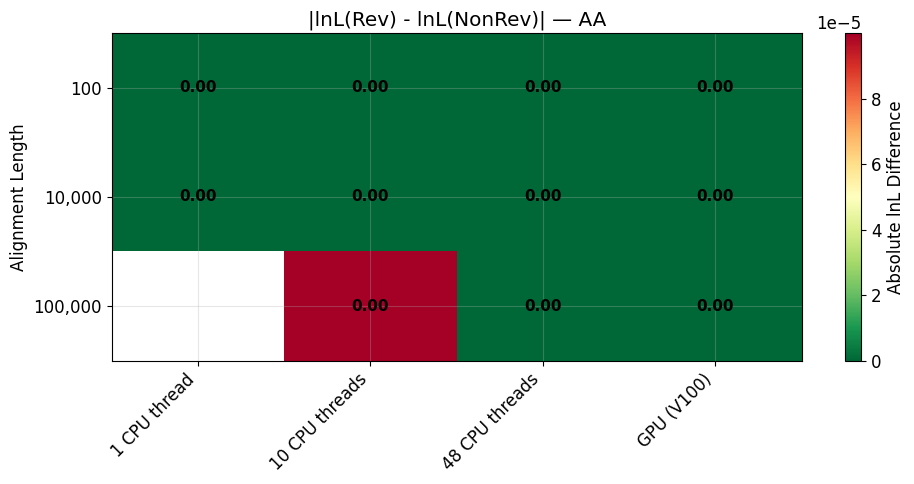

In [16]:
# Log-likelihood difference heatmap (AA)
if 'abs_diff' in lnl_comp_aa.columns:
    diff_pivot_aa = lnl_comp_aa['abs_diff'].unstack(level='backend_label')
    diff_pivot_aa = diff_pivot_aa[[c for c in backend_order if c in diff_pivot_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    im = ax.imshow(diff_pivot_aa.values, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(len(diff_pivot_aa.columns)))
    ax.set_xticklabels(diff_pivot_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(diff_pivot_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in diff_pivot_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('|lnL(Rev) - lnL(NonRev)| — AA')

    for i in range(len(diff_pivot_aa.index)):
        for j in range(len(diff_pivot_aa.columns)):
            val = diff_pivot_aa.iloc[i, j]
            if not pd.isna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11, fontweight='bold')

    plt.colorbar(im, ax=ax, label='Absolute lnL Difference')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_lnl_diff_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Wall-Clock Runtime Comparison (AA)

In [17]:
# Wall-clock time pivot table (AA)
time_comp_aa = df_aa.pivot_table(index=['length', 'backend_label'], columns='kernel_label', values='wall_time_sec', aggfunc='first')
if 'Kernel-Rev' in time_comp_aa.columns and 'Kernel-NonRev' in time_comp_aa.columns:
    time_comp_aa['ratio_rev_over_nonrev'] = time_comp_aa['Kernel-Rev'] / time_comp_aa['Kernel-NonRev']
    time_comp_aa['pct_change'] = (time_comp_aa['Kernel-Rev'] - time_comp_aa['Kernel-NonRev']) / time_comp_aa['Kernel-NonRev'] * 100

print("Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)")
print("ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER")
print("=" * 90)
time_comp_aa.round(3)

Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)
ratio < 1 means Rev is FASTER; ratio > 1 means Rev is SLOWER


kernel_label           Kernel-NonRev  Kernel-Rev  ratio_rev_over_nonrev  \
length backend_label                                                      
100    1 CPU thread           75.742      44.990                  0.594   
       10 CPU threads         37.485      11.793                  0.315   
       48 CPU threads         43.844      16.590                  0.378   
       GPU (V100)             83.831      83.891                  1.001   
10000  1 CPU thread         4404.090    5099.420                  1.158   
       10 CPU threads        534.524     574.299                  1.074   
       48 CPU threads        278.756     192.261                  0.690   
       GPU (V100)            221.722     222.621                  1.004   
100000 10 CPU threads       3690.998    4912.561                  1.331   
       48 CPU threads       1288.688    1417.731                  1.100   
       GPU (V100)            959.530     956.770                  0.997   

kernel_label           pct_change  
length backend_label               
100    1 CPU thread       -40.601  
       10 CPU threads     -68.539  
       48 CPU threads     -62.161  
       GPU (V100)           0.072  
10000  1 CPU thread        15.788  
       10 CPU threads       7.441  
       48 CPU threads     -31.029  
       GPU (V100)           0.405  
100000 10 CPU threads      33.096  
       48 CPU threads      10.014  
       GPU (V100)          -0.288

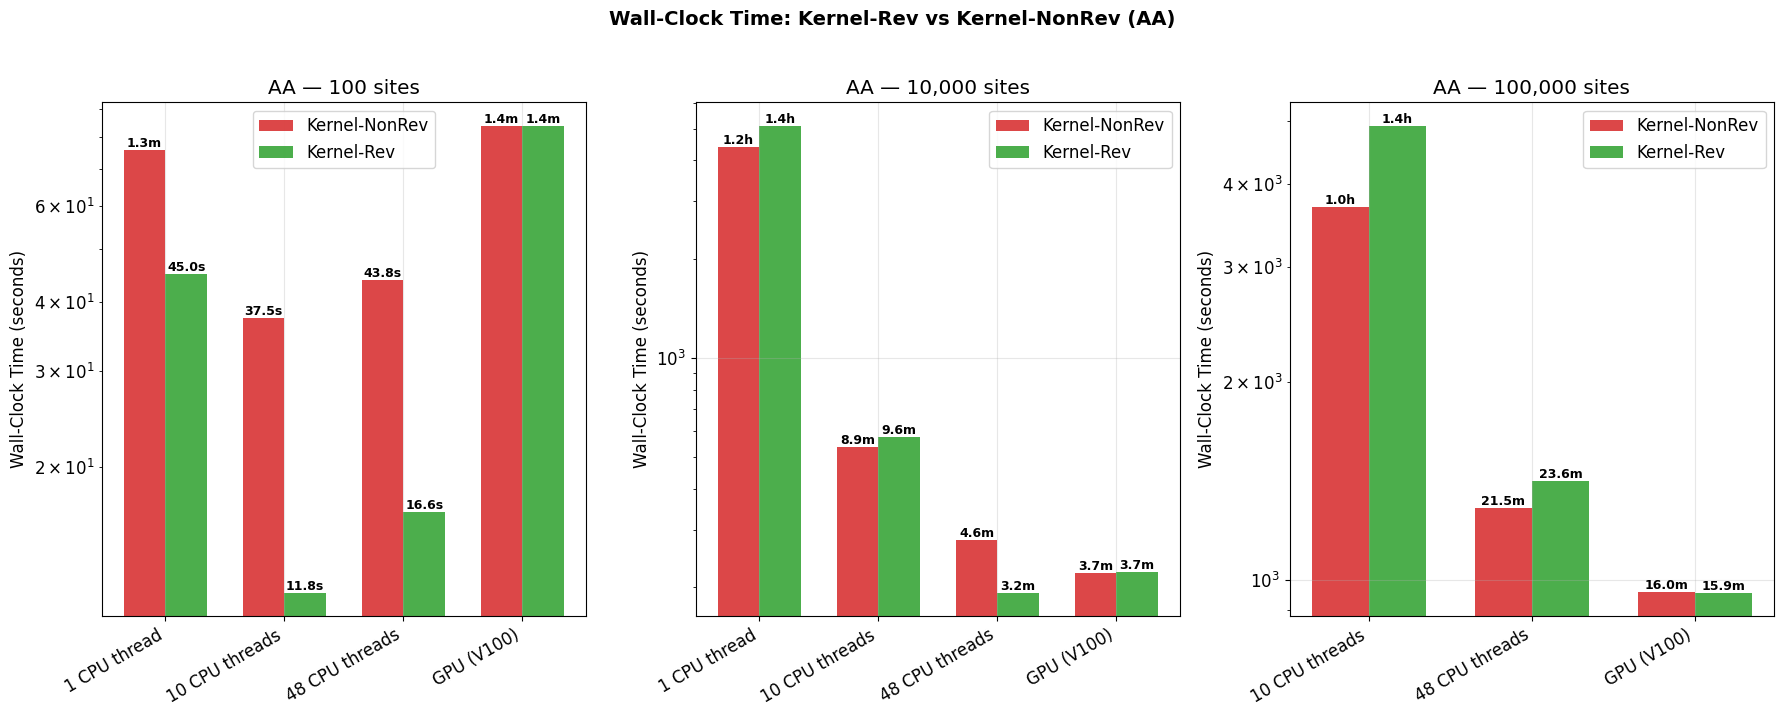

In [18]:
# Grouped bar chart: wall-clock time rev vs nonrev per backend (AA)
aa_lengths = sorted(df_aa['length'].unique())
n_lengths_aa = len(aa_lengths)

fig, axes = plt.subplots(1, n_lengths_aa, figsize=(6 * n_lengths_aa, 7), sharey=False)
if n_lengths_aa == 1: axes = [axes]

for ax, length in zip(axes, aa_lengths):
    sub = df_aa[df_aa['length'] == length]
    backends_present = [b for b in backend_order if b in sub['backend_label'].values]
    x = np.arange(len(backends_present))
    width = 0.35

    rev_times = []
    nonrev_times = []
    for b in backends_present:
        rev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-Rev')]['wall_time_sec']
        nonrev_val = sub[(sub['backend_label'] == b) & (sub['kernel_label'] == 'Kernel-NonRev')]['wall_time_sec']
        rev_times.append(rev_val.values[0] if len(rev_val) > 0 else 0)
        nonrev_times.append(nonrev_val.values[0] if len(nonrev_val) > 0 else 0)

    bars1 = ax.bar(x - width/2, nonrev_times, width, label='Kernel-NonRev', color=kernel_colors['Kernel-NonRev'], alpha=0.85)
    bars2 = ax.bar(x + width/2, rev_times, width, label='Kernel-Rev', color=kernel_colors['Kernel-Rev'], alpha=0.85)

    for bar_group in [bars1, bars2]:
        for bar in bar_group:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h, fmt_time(h),
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(backends_present, rotation=30, ha='right')
    ax.set_ylabel('Wall-Clock Time (seconds)')
    ax.set_title(f'AA — {length:,} sites')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Wall-Clock Time: Kernel-Rev vs Kernel-NonRev (AA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'aa_walltime_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Speedup Ratio: NonRev/Rev (AA)

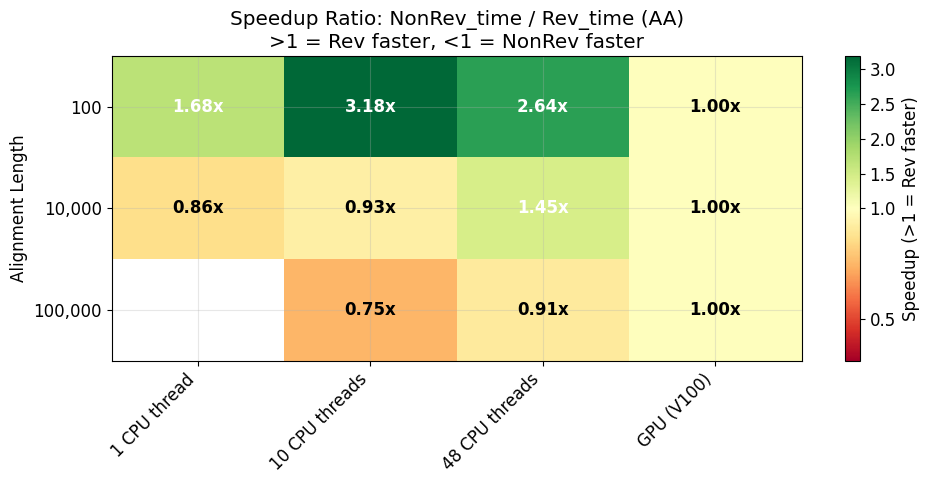

In [19]:
# Speedup heatmap (AA)
if 'Kernel-Rev' in time_comp_aa.columns and 'Kernel-NonRev' in time_comp_aa.columns:
    speedup_aa = (time_comp_aa['Kernel-NonRev'] / time_comp_aa['Kernel-Rev']).unstack(level='backend_label')
    speedup_aa = speedup_aa[[c for c in backend_order if c in speedup_aa.columns]]

    fig, ax = plt.subplots(figsize=(10, 5))
    from matplotlib.colors import TwoSlopeNorm
    vmin_aa = min(speedup_aa.min().min(), 1/speedup_aa.max().max())
    vmax_aa = max(speedup_aa.max().max(), 1/speedup_aa.min().min())
    norm_aa = TwoSlopeNorm(vmin=vmin_aa, vcenter=1.0, vmax=vmax_aa)

    im = ax.imshow(speedup_aa.values, cmap='RdYlGn', norm=norm_aa, aspect='auto')
    ax.set_xticks(range(len(speedup_aa.columns)))
    ax.set_xticklabels(speedup_aa.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(speedup_aa.index)))
    ax.set_yticklabels([f'{l:,}' for l in speedup_aa.index])
    ax.set_ylabel('Alignment Length')
    ax.set_title('Speedup Ratio: NonRev_time / Rev_time (AA)\n>1 = Rev faster, <1 = NonRev faster')

    for i in range(len(speedup_aa.index)):
        for j in range(len(speedup_aa.columns)):
            val = speedup_aa.iloc[i, j]
            if not pd.isna(val):
                color = 'white' if abs(val - 1) > 0.3 else 'black'
                ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

    plt.colorbar(im, ax=ax, label='Speedup (>1 = Rev faster)')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'aa_speedup_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()